In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import sxs 
from sxs.julia import PNWaveform
from scipy.signal import savgol_filter 
from matplotlib.lines import Line2D

plt.style.use("~/PhD/subdom_asym/code_subdom_asym/MATPLOTLIB_RCPARAMS.sty")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
def h_minus(h, l, m):
    '''
    Returns the anti-symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    return (h[(l,m)] - (-1)**l * np.conjugate(h[(l,-m)]))/2


#-----------------------------------------------------------------------------------------------------


def a_minus(h, l, m):
    '''
    Returns the amplitude of the anti-symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = np.abs(h_minus(h, l, m))
    return a 


#-----------------------------------------------------------------------------------------------------


def a_minus_dot(h, t, l, m):
    '''
    Returns the amplitude np.gradientative of the anti-symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = a_minus(h, l, m)
    return np.gradient(a, t)


#-----------------------------------------------------------------------------------------------------


def phi_minus(h, l, m):
    '''
    Returns the phase of the anti-symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = np.unwrap(np.angle(h_minus(h, l, m)))
    return phi 


#-----------------------------------------------------------------------------------------------------


def phi_minus_dot(h, t, l, m):
    '''
    Returns the phase np.gradientative of the anti-symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = phi_minus(h, l, m)
    return np.gradient(phi, t)


#-----------------------------------------------------------------------------------------------------

    
def h_plus(h, l, m):
    '''
    Returns the symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    return (h[(l,m)] + (-1)**l * np.conjugate(h[(l,-m)]))/2    


#-----------------------------------------------------------------------------------------------------


def a_plus(h, l, m):
    '''
    Returns the amplitude of the symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = np.abs(h_plus(h, l, m)) 
    return a


#-----------------------------------------------------------------------------------------------------


def a_plus_dot(h, t, l, m):
    '''
    Returns the amplitude np.gradientative of the symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    a = a_plus(h, l, m)
    return np.gradient(a, t)


#-----------------------------------------------------------------------------------------------------


def phi_plus(h, l, m):
    '''
    Returns the phase of the symmetric waveform 
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = np.unwrap(np.angle(h_plus(h, l, m))) 
    return phi 


#-----------------------------------------------------------------------------------------------------


def phi_plus_dot(h, t, l, m):
    '''
    Returns the phase np.gradientative of the symmetric waveform
    h:  mode dictionary with (l, m) tuples as keys (dict)
    l:  greater equal 2 (int) 
    m:  greater equal 1 less equal l (int)
    '''
    phi = phi_plus(h, l, m)
    return np.gradient(phi, t) 


In [3]:
def get_metadata(sxs_id):

    sxs_bbh = sxs.load(sxs_id)
    chi1 = sxs_bbh.metadata.reference_dimensionless_spin1
    chi2 = sxs_bbh.metadata.reference_dimensionless_spin2
    m1 = sxs_bbh.metadata.reference_mass1
    m2 = sxs_bbh.metadata.reference_mass2
    omega_ref = np.linalg.norm(sxs_bbh.metadata.reference_orbital_frequency)

    return m1, m2, chi1, chi2, omega_ref


#-----------------------------------------------------------------------------------------------------


def trim_sxs_waveform(sxs_id):

    sxs_bbh = sxs.load(sxs_id)
    wf = sxs_bbh.h
    time = wf.t
    t_peak = wf.max_norm_time()
    t_ref = sxs_bbh.metadata.reference_time
    idx_ref = wf.index_closest_to(t_ref)
    wf = wf[idx_ref:]
    time = time[idx_ref:] - t_peak

    return wf, time


#-----------------------------------------------------------------------------------------------------


def to_mode_dict(wf):

    data = wf.data.T
    mode_list = [(ell, m) for ell in range(wf.ell_min, wf.ell_max + 1)
                          for m in range(-ell, ell + 1)]
    
    return dict(zip(mode_list, data))


#-----------------------------------------------------------------------------------------------------


def filter(x):

    return savgol_filter(x, int(len(x)/20), 3)



#-----------------------------------------------------------------------------------------------------


def orbital_phase_PN(sxs_id):

    m1, m2, chi1, chi2, omega_ref = get_metadata(sxs_id)
    wf = PNWaveform(m1, m2, chi1, chi2, omega_ref)

    return wf.t, wf.orbital_phase


#-----------------------------------------------------------------------------------------------------


def h_copr_from_sxs(sxs_id):

    wf, time = trim_sxs_waveform(sxs_id)
    wf_copr = wf.to_coprecessing_frame()

    return time, to_mode_dict(wf_copr)


#-----------------------------------------------------------------------------------------------------


def h_copr_from_PN(sxs_id):

    m1, m2, chi1, chi2, omega_ref = get_metadata(sxs_id)
    wf = PNWaveform(m1, m2, chi1, chi2, omega_ref)
    wf_interp = wf.interpolate(np.arange(wf.t[0], wf.t[-1], 0.1))
    wf_copr = wf_interp.to_coprecessing_frame()

    return wf_copr.t, to_mode_dict(wf_copr)


#-----------------------------------------------------------------------------------------------------


def h_coro_from_sxs(sxs_id):

    wf, time = trim_sxs_waveform(sxs_id)
    wf_coro = wf.to_corotating_frame()

    return time, to_mode_dict(wf_coro)


#-----------------------------------------------------------------------------------------------------


def h_coro_from_PN(sxs_id):

    m1, m2, chi1, chi2, omega_ref = get_metadata(sxs_id)
    wf = PNWaveform(m1, m2, chi1, chi2, omega_ref)
    wf_interp = wf.interpolate(np.arange(wf.t[0], wf.t[-1], 0.1))
    wf_coro = wf_interp.to_corotating_frame()
    
    return wf_coro.t, to_mode_dict(wf_coro)


In [4]:
sxs_id = 'SXS:BBH:1207' #'SXS:BBH:1207'  
t_phi_orb_PN, phi_orb_PN = orbital_phase_PN(sxs_id)
t_copr, h_copr = h_copr_from_sxs(sxs_id) 
t_PN, h_copr_PN = h_copr_from_PN(sxs_id)
t_coro, h_coro = h_coro_from_sxs(sxs_id) 
t_PN, h_coro_PN = h_coro_from_PN(sxs_id)

Loading SXS simulations using latest tag 'v3.0.0', published at 2025-05-14T18:17:30Z.


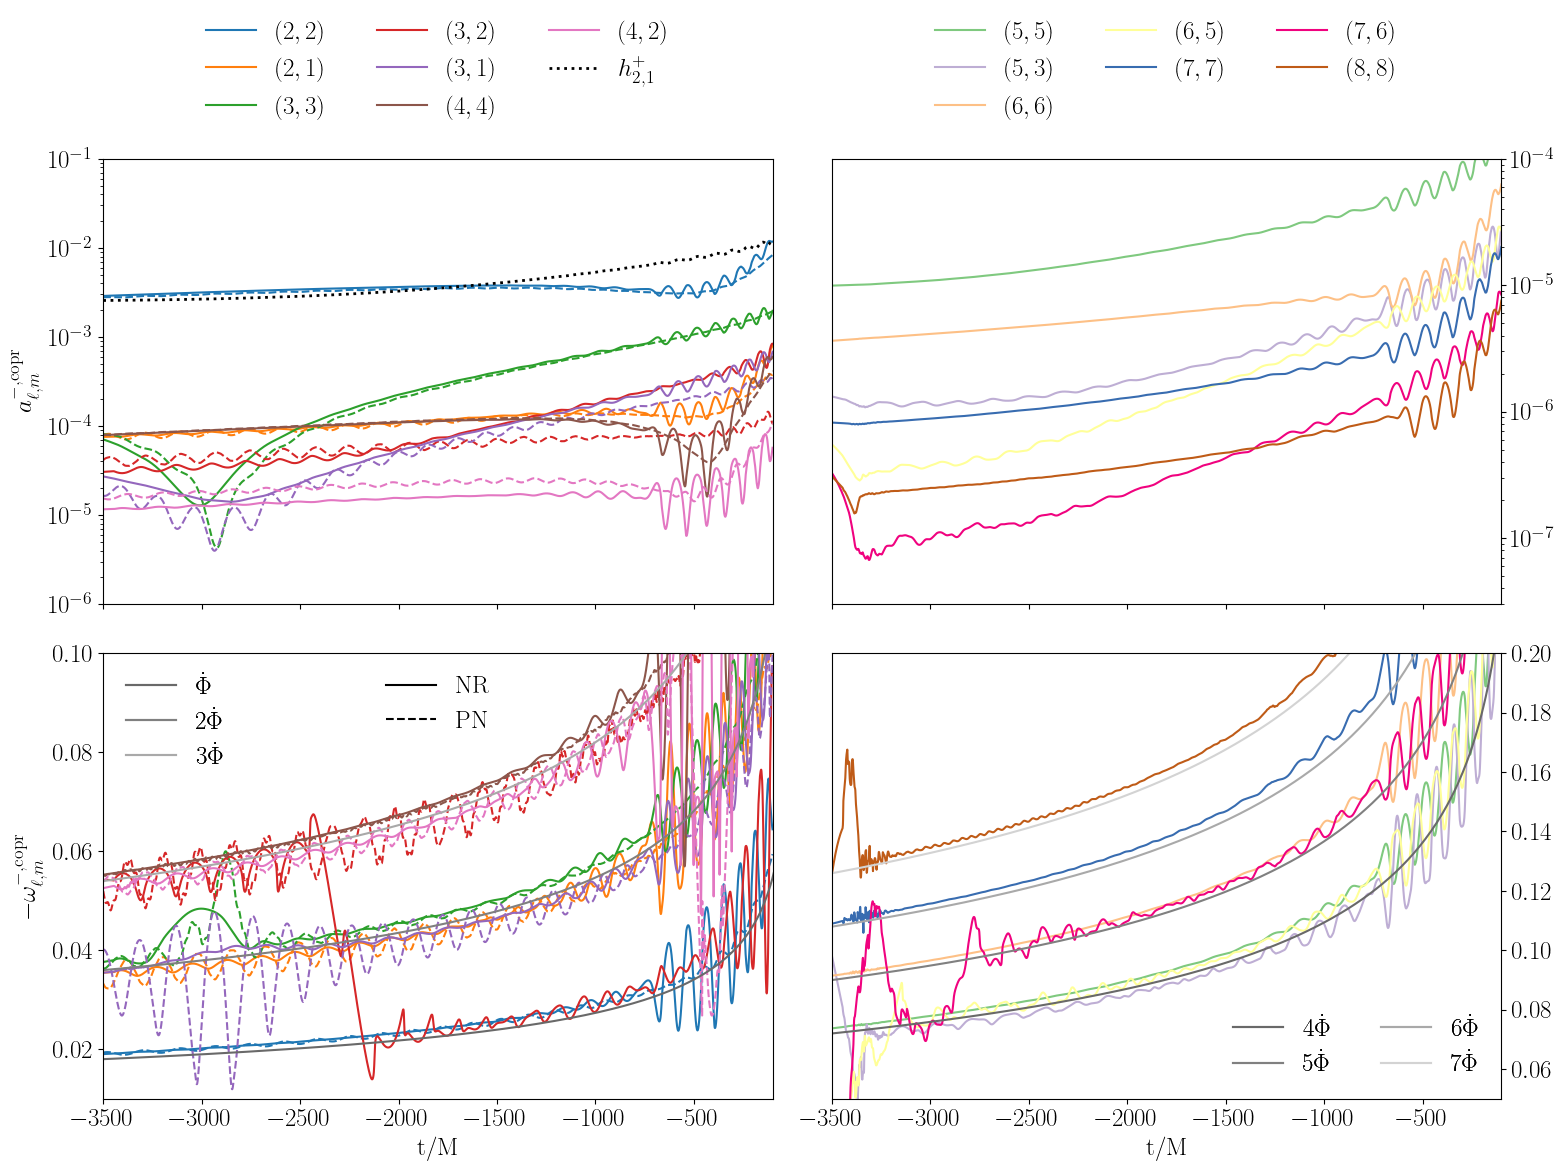

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(16,12))


PN_mode_list = [(2,2), (2,1), (3,3), (3,2), (3,1), (4,4), (4,2)]
higher_mode_list = [(5,5), (5,3), (6,6), (6,5), (7,7), (7,6), (8,8)]
PN_colors = plt.cm.tab10.colors
higher_mode_colors = plt.cm.Accent.colors

# --- Plot 1 ---
ax1 = axes[0,0]

for i, (ell, m) in enumerate(PN_mode_list):
    color = PN_colors[i % len(PN_colors)]
    ax1.semilogy(t_copr, filter(a_minus(h_copr, ell, m)),
                 label=rf'${ell,m}$', color=color)
    ax1.semilogy(t_PN + t_copr[0], filter(a_minus(h_copr_PN, ell, m)),
                 '--', color=color)
    
ax1.semilogy(t_copr, filter(a_plus(h_copr, 2, 1)),
                 label=r'$h^+_{2,1}$', color='black', ls=':', linewidth=2)

ax1.set_xlim(-3500, -100)
ax1.set_ylim(1e-6, 1e-1)
ax1.set_ylabel(r'$a^{-,\text{copr}}_{\ell,m}$')
ax1.legend(loc="center", bbox_to_anchor=(0.5, 1.2), frameon=False, ncol=3)



# --- Plot 2 ---
ax2 = axes[0,1]

for i, (ell, m) in enumerate(higher_mode_list):
    color = higher_mode_colors[i % len(higher_mode_colors)]
    ax2.semilogy(t_copr, filter(a_minus(h_copr, ell, m)),
                 label=rf'${ell,m}$', color=color)

ax2.set_ylim(3e-8, 1e-4)
ax2.set_xlim(-3500, -100)
ax2.legend(loc="center", bbox_to_anchor=(0.5, 1.2), frameon=False, ncol=3)
ax2.yaxis.tick_right()


# --- Plot 3 ---
ax3 = axes[1,0]

for i, (ell, m) in enumerate(PN_mode_list):
    color = PN_colors[i % len(PN_colors)]
    ax3.plot(t_copr, filter(-phi_minus_dot(h_copr, t_copr, ell, m)), color=color)
    ax3.plot(t_PN + t_copr[0], filter(-phi_minus_dot(h_copr_PN, t_PN, ell, m)), '--', color=color)

Phi_orb_dot = np.gradient(phi_orb_PN, t_phi_orb_PN)
ax3.plot(t_phi_orb_PN+t_copr[0], Phi_orb_dot, color='dimgray')
ax3.plot(t_phi_orb_PN+t_copr[0], 2*Phi_orb_dot, color='grey')
ax3.plot(t_phi_orb_PN+t_copr[0], 3*Phi_orb_dot, color='darkgrey')

ax3.set_xlim(-3500, -100)
ax3.set_ylim(0.01, 0.1)
ax3.set_ylabel(r'$-\omega^{-,\text{copr}}_{\ell,m}$')
ax3.set_xlabel('t/M')

ax3.add_artist(ax3.legend(handles=[
    Line2D([0], [0], color='black', linestyle='-', label='NR'),
    Line2D([0], [0], color='black', linestyle='--', label='PN')],
    loc="upper center", frameon=False))

ax3.add_artist(ax3.legend(handles=[
    Line2D([0], [0], color='dimgray', label=r'$\dot{\Phi}$'),
    Line2D([0], [0], color='grey', label=r'$2\dot{\Phi}$'),
    Line2D([0], [0], color='darkgrey', label=r'$3\dot{\Phi}$')],
    loc="upper left", frameon=False))



# --- Plot 4 ---
ax4 = axes[1,1]

for i, (ell, m) in enumerate(higher_mode_list):
    color = higher_mode_colors[i % len(higher_mode_colors)]
    ax4.plot(t_copr, filter(-phi_minus_dot(h_copr, t_copr, ell, m)), color=color)

Phi_orb_dot = np.gradient(phi_orb_PN, t_phi_orb_PN)
ax4.plot(t_phi_orb_PN+t_copr[0], 4*Phi_orb_dot, color='dimgray')
ax4.plot(t_phi_orb_PN+t_copr[0], 5*Phi_orb_dot, color='grey')
ax4.plot(t_phi_orb_PN+t_copr[0], 6*Phi_orb_dot, color='darkgrey')
ax4.plot(t_phi_orb_PN+t_copr[0], 7*Phi_orb_dot, color='lightgrey')

ax4.set_xlim(-3500, -100)
ax4.set_ylim(0.05, 0.2)
ax4.set_xlabel('t/M')
ax4.yaxis.tick_right()

ax4.add_artist(ax4.legend(handles=[
    Line2D([0], [0], color='dimgray', label=r'$4\dot{\Phi}$'),
    Line2D([0], [0], color='grey', label=r'$5\dot{\Phi}$'),
    Line2D([0], [0], color='darkgrey', label=r'$6\dot{\Phi}$'),
    Line2D([0], [0], color='lightgrey', label=r'$7\dot{\Phi}$')],
    loc="lower right", frameon=False, ncol=2))

plt.tight_layout()
# plt.savefig('inspiral_asym_wf.pdf', bbox_inches='tight')
plt.show()

In [6]:
sxs.cite('SXS:BBH:1207')

'@misc{SXSPackage_v2025.0.16,\n  doi = {10.5281/ZENODO.15547069},\n  url = {https://zenodo.org/doi/10.5281/zenodo.15547069},\n  author = {Boyle, Michael and Mitman, Keefe and Scheel, Mark and Stein, Leo},\n  title = {The sxs package},\n  publisher = {Zenodo},\n  year = {2025},\n  copyright = {MIT License}\n}\n\n@misc{SXSCatalogPaper_3,\n  doi = {10.26138/SXSCATALOG3},\n  url = {https://arxiv.org/abs/2505.13378},\n  author = {{SXS Collaboration}},\n  title = {The third SXS collaboration catalog of binary black-hole simulations},\n  publisher = {SXS Collaboration},\n  year = {2025}\n}\n\n@misc{SXSCatalogData_3.0.0,\n  doi = {10.5281/ZENODO.15415231},\n  url = {https://zenodo.org/doi/10.5281/zenodo.15415231},\n  author = {{SXS Collaboration}},\n  title = {The SXS catalog of simulations v3.0.0},\n  publisher = {Zenodo},\n  year = {2025},\n  copyright = {Creative Commons Attribution 4.0 International}\n}\n\n@article{Boyle_2019,\n  title = {The SXS collaboration catalog of binary black hole 